In [20]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os
from statsmodels.tsa.vector_ar.vecm import VECM
from Src.Feature_engineering import feature_engineering


load_dotenv()

##Connect to sql database
engine = create_engine(
    f"mysql+pymysql://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@"
    f"{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DB')}"
)




In [21]:
data_i1_reorder,exogenous_variables= feature_engineering()
print(data_i1_reorder)
print(exogenous_variables)

     Government Spending  Investment  Labor Productivity  GDP_per_capita  \
0               1811.988    2243.548                 4.1        0.033868   
1               1816.961    2244.682                 3.9        0.034195   
2               1843.205    2306.470                 3.5        0.034663   
3               1875.154    2367.988                 4.2        0.035315   
4               1866.308    2351.223                 2.4        0.035584   
..                   ...         ...                 ...             ...   
102             7165.663    4392.176                 2.6        0.086685   
103             7247.662    4315.564                 1.9        0.087463   
104             7313.597    4547.947                 1.2        0.087983   
105             7496.339    4382.819                 1.5        0.089172   
106             7580.229    4383.186                 1.9        0.090832   

     Inflation  
0     2.383116  
1     2.226592  
2     2.111144  
3     2.049620  
4 

In [22]:
model=VECM(data_i1_reorder, k_ar_diff=2, coint_rank=2, deterministic='ci',exog=exogenous_variables)
vecm_res=model.fit()
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
exog1,339.4471,14.333,23.684,0.000,311.356,367.538
exog2,64.5857,8.300,7.782,0.000,48.319,80.853
L1.Government Spending,-0.3385,0.070,-4.828,0.000,-0.476,-0.201
L1.Investment,-1.6910,0.240,-7.050,0.000,-2.161,-1.221
L1.Labor Productivity,-48.7887,17.592,-2.773,0.006,-83.269,-14.308
L1.GDP_per_capita,9.01e+04,3.77e+04,2.391,0.017,1.63e+04,1.64e+05
L1.Inflation,-31.1861,78.360,-0.398,0.691,-184.769,122.397
L2.Government Spending,-0.3712,0.070,-5.296,0.000,-0.509,-0.234
L2.Investment,-0.9663,0.254,-3.803,0.000,-1.464,-0.468
L2.Labor Productivity,17.5694,16.468,1.067,0.286,-14.708,49.847


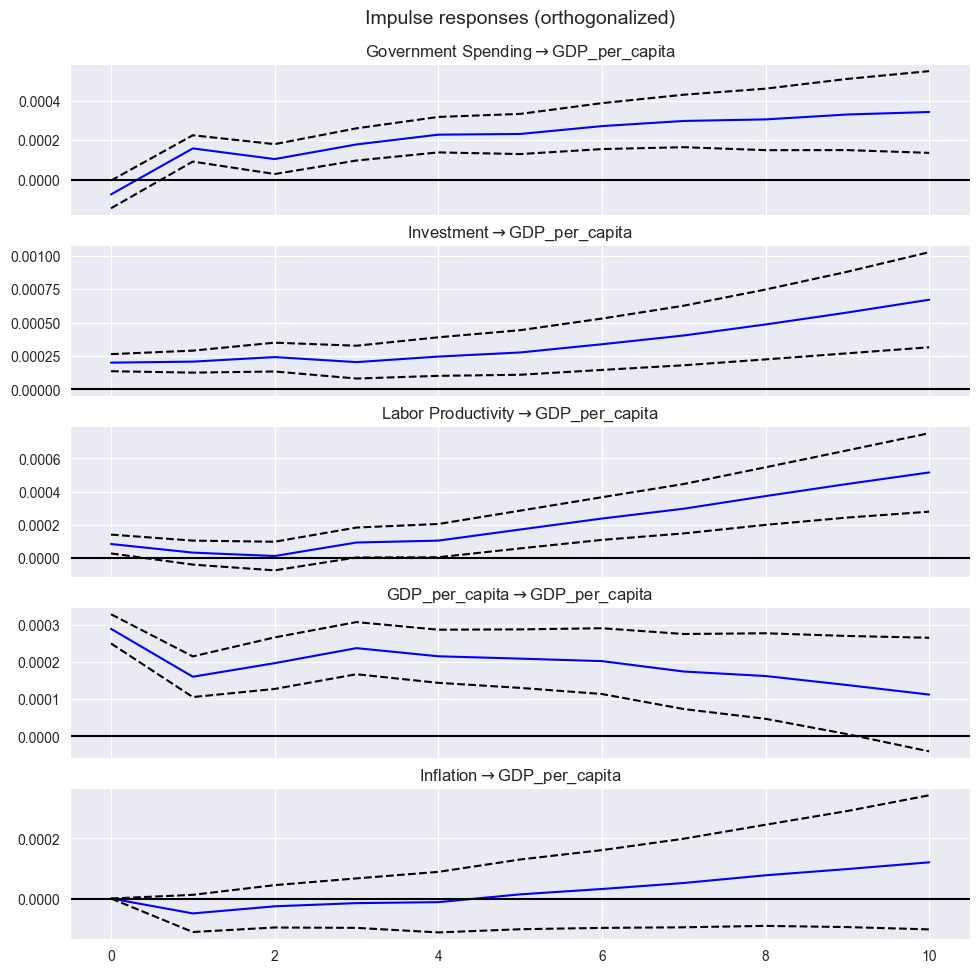

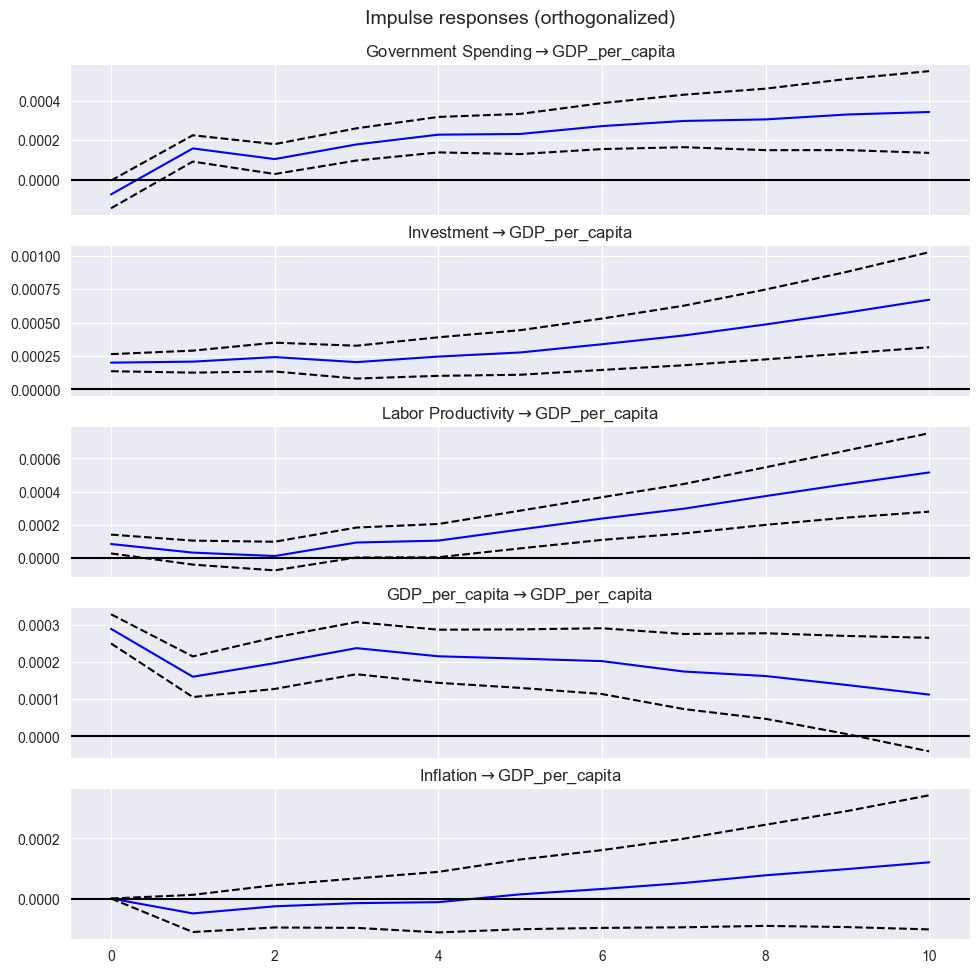

In [23]:
irf = vecm_res.irf(periods=10)
irf.plot(orth=True,response="GDP_per_capita")